# 11-Cluster Debugging & Observability (Prometheus & Grafana)

Lessons 07-10 each solved a specific distributed-training failure mode -- checkpoint loss, poor GPU placement, pipeline bottlenecks, communication-tier mismatches -- by reasoning about it directly. In production none of those failure modes announce themselves; they show up first as a vague symptom on a dashboard (throughput dipped, queue depth climbed, a training job feels "slow") and someone has to work backward from metrics to root cause. That backward inference is only tractable if the metrics themselves are trustworthy and the alerting built on top of them fires on real problems without drowning the team in noise.

**Prometheus** scrapes and stores cluster metrics as time series; **Grafana** visualizes them. The genuinely hard engineering problem underneath both tools is not collection, it is *alerting math*: naive threshold alerts either fire constantly on noise or stay silent through real incidents, and the fix -- multi-window, multi-burn-rate alerting -- is a rigorous application of error-budget accounting, not a UI feature.

We will simulate realistic cluster telemetry (GPU utilization, scheduling queue depth, request latency), implement Prometheus's core `rate()` and `histogram_quantile()` query semantics in pure Python, and run Google SRE's multi-window burn-rate alerting algorithm against an injected incident -- the tool for this lesson is **Prometheus & Grafana**.

## 1. The Mathematics of Metrics, SLOs, and Burn-Rate Alerting

### The Counter and rate() Semantics

Prometheus counters are monotonically increasing; the actual signal of interest is their rate of change. For a counter series sampled at times $t_1, t_2$ with values $v_1, v_2$, the instantaneous rate over that range vector is:

$$\text{rate}(x)[t_1, t_2] = \frac{v_2 - v_1}{t_2 - t_1}$$

This is exactly why counters must never be read directly on a dashboard -- a raw counter value tells you cumulative total requests since process start, `rate()` tells you requests per second *right now*, and only the latter is operationally meaningful.

### Error Budgets and Burn Rate

An SLO target of $99.9\%$ success rate over a 30-day window defines an **error budget**: the maximum tolerable fraction of failed requests, $E = 1 - \text{SLO} = 0.001$. **Burn rate** measures how fast that budget is being consumed relative to a sustainable pace:

$$\text{BurnRate} = \frac{\text{observed error rate}}{E}$$

A burn rate of $1.0$ means the service is failing exactly fast enough to exhaust its entire 30-day budget in exactly 30 days -- the maximum sustainable pace. A burn rate of $10$ means the budget would be fully exhausted in $30/10 = 3$ days if sustained.

### Multi-Window, Multi-Burn-Rate Alerting

A single-window threshold alert (e.g. "page if error rate over the last 5 minutes exceeds X") is provably unreliable: a short window is *noisy* (single-request blips false-page) and a long window is *slow* (a real outage takes hours to cross the threshold). Google's SRE workbook solves this by requiring agreement across **two windows of different length simultaneously**:

$$\text{Alert} \iff \text{BurnRate}_{\text{long}}(t) > \theta \;\land\; \text{BurnRate}_{\text{short}}(t) > \theta$$

The long window (e.g. 1h) confirms the burn is sustained, not a blip; the short window (e.g. 5m) confirms the problem is still happening *right now*, not something that already resolved. Requiring both collapses false-positive rate dramatically while keeping detection latency low, because the long window alone would take an hour to fire and the short window alone would fire on noise.

### Histogram Quantiles from Bucketed Data

Prometheus histograms store cumulative counts per upper-bound bucket $\text{le}_i$. To estimate the $p$-th percentile, find the bucket $\text{le}_k$ where the cumulative count first exceeds $p \cdot \text{total}$, then linearly interpolate within that bucket:

$$\hat{q}_p = \text{le}_{k-1} + (\text{le}_k - \text{le}_{k-1}) \cdot \frac{p \cdot \text{total} - \text{count}_{k-1}}{\text{count}_k - \text{count}_{k-1}}$$

This interpolation is an approximation -- true precision is bounded by bucket granularity -- which is exactly why choosing histogram bucket boundaries is itself a real observability design decision, not an afterthought.

### GPU Job Queue as an M/M/c Queueing System

Pending GPU jobs waiting for a scheduler slot behave like an M/M/c queue: jobs arrive at rate $\lambda$, are served by $c$ parallel "servers" (available GPU slots) each at rate $\mu$. Utilization is $\rho = \lambda / (c\mu)$, and for $\rho < 1$ (a stable, non-diverging queue) the expected wait time before service (via the Erlang-C formula's mean-value consequence) grows sharply as $\rho \to 1$:

$$\mathbb{E}[\text{wait}] \propto \frac{\rho}{1 - \rho}$$

a queue-depth metric climbing on a dashboard is this formula's numerator-over-denominator relationship playing out in real time -- small increases in $\rho$ near saturation cause disproportionate waiting-time blowups.

## 2. Imperative Execution: Simulated Telemetry With an Injected Incident

We generate realistic multi-metric cluster telemetry (GPU utilization, p95 request latency, error rate) as real time series, inject a genuine 20-minute incident partway through, and implement Prometheus's `rate()` and `histogram_quantile()` query semantics from Section 1 directly against the simulated data.

In [1]:
# Required installations: pip install numpy pandas (prometheus_client / a live Prometheus+Grafana stack are not available in this sandbox)

import numpy as np
import pandas as pd

print("--- 🚀 Initializing Prometheus/Grafana Cluster Observability Sandbox ---")

np.random.seed(42)

N_MINUTES = 180
INCIDENT_START, INCIDENT_END = 100, 120  # minutes into the window

timestamps = np.arange(N_MINUTES)

# 1. Simulate a real-looking error-count counter (monotonically increasing) with a request-count counter alongside it
baseline_error_rate = 0.0005  # 0.05% baseline error rate, comfortably inside a 99.9% SLO's budget
incident_error_rate = 0.08    # 8% error rate during the injected incident -- a real outage-magnitude spike

request_counts = np.random.poisson(500, size=N_MINUTES)  # ~500 req/min baseline traffic
error_rate_per_min = np.where(
    (timestamps >= INCIDENT_START) & (timestamps < INCIDENT_END), incident_error_rate, baseline_error_rate
)
error_counts = np.random.binomial(request_counts, error_rate_per_min)

requests_cumulative = np.cumsum(request_counts)   # a real Prometheus-style monotonic counter
errors_cumulative = np.cumsum(error_counts)        # a real Prometheus-style monotonic counter

print(f"   ✅ Simulated {N_MINUTES} minutes of request/error counters, incident injected at "
      f"t={INCIDENT_START}-{INCIDENT_END}min (error rate {incident_error_rate:.0%} vs baseline {baseline_error_rate:.2%})")


def prom_rate(cumulative_series, window):
    """Real Prometheus rate() semantics: (v2 - v1) / (t2 - t1) over a trailing range-vector window."""
    rates = np.full(len(cumulative_series), np.nan)
    for t in range(window, len(cumulative_series)):
        rates[t] = (cumulative_series[t] - cumulative_series[t - window]) / window
    return rates


error_rate_5m = prom_rate(errors_cumulative, 5) / np.maximum(prom_rate(requests_cumulative, 5), 1e-9)
error_rate_60m = prom_rate(errors_cumulative, 60) / np.maximum(prom_rate(requests_cumulative, 60), 1e-9)

print("\n--- 🧮 Executing Real Prometheus rate() Queries Over Two Windows ---")
print(f"   ✅ error_rate_5m computed:  peak={np.nanmax(error_rate_5m):.4f} at t={np.nanargmax(error_rate_5m)}min")
print(f"   ✅ error_rate_60m computed: peak={np.nanmax(error_rate_60m):.4f} at t={np.nanargmax(error_rate_60m)}min")

# 2. Simulate a real Prometheus-style latency histogram (bucketed) and interpolate p95 with histogram_quantile()
latency_buckets_ms = [10, 25, 50, 100, 250, 500, 1000, float("inf")]
sample_latencies = np.concatenate([
    np.random.gamma(shape=2.0, scale=15, size=900),
    np.random.gamma(shape=2.0, scale=15, size=100) + 400,  # a slow tail
])


def histogram_quantile(p, buckets, samples):
    counts = [np.sum(samples <= b) for b in buckets]
    total = counts[-1]
    target = p * total
    for i in range(len(buckets)):
        if counts[i] >= target:
            lower_bound = buckets[i - 1] if i > 0 else 0
            lower_count = counts[i - 1] if i > 0 else 0
            if counts[i] == lower_count:
                return lower_bound
            frac = (target - lower_count) / (counts[i] - lower_count)
            upper_bound = buckets[i] if buckets[i] != float("inf") else lower_bound * 2
            return lower_bound + (upper_bound - lower_bound) * frac
    return buckets[-2]


p95_latency = histogram_quantile(0.95, latency_buckets_ms, sample_latencies)
print(f"\n   ✅ histogram_quantile(0.95, ...) = {p95_latency:.1f}ms (interpolated from {len(latency_buckets_ms)} real buckets)")


--- 🚀 Initializing Prometheus/Grafana Cluster Observability Sandbox ---
   ✅ Simulated 180 minutes of request/error counters, incident injected at t=100-120min (error rate 8% vs baseline 0.05%)

--- 🧮 Executing Real Prometheus rate() Queries Over Two Windows ---
   ✅ error_rate_5m computed:  peak=0.0878 at t=115min
   ✅ error_rate_60m computed: peak=0.0264 at t=124min

   ✅ histogram_quantile(0.95, ...) = 375.0ms (interpolated from 8 real buckets)


## 3. Declarative Telemetry: The Multi-Window Burn-Rate Alerting Audit

We run Google SRE's multi-window, multi-burn-rate algorithm from Section 1 against the simulated incident, comparing it minute-by-minute against a naive single-window threshold alert -- the exact comparison an on-call engineer cares about: which approach pages promptly on the real incident without also paging on ordinary noise.

In [2]:
SLO_TARGET = 0.999
ERROR_BUDGET = 1 - SLO_TARGET  # 0.001
BURN_RATE_THRESHOLD = 14.4  # standard Google SRE workbook threshold for a "page now" 1h/5m alert pair

print("\n--- 🔍 Auditing Multi-Window Burn-Rate Alerting vs. Naive Single-Window Threshold ---")

burn_rate_5m = error_rate_5m / ERROR_BUDGET
burn_rate_60m = error_rate_60m / ERROR_BUDGET

multi_window_alert = (burn_rate_5m > BURN_RATE_THRESHOLD) & (burn_rate_60m > BURN_RATE_THRESHOLD)
naive_alert = error_rate_5m > 0.02  # a naive fixed 2% error-rate threshold on the short window alone

mw_fire_minutes = np.where(multi_window_alert)[0]
naive_fire_minutes = np.where(naive_alert)[0]

print(f"{'Metric':<38} | {'Value'}")
print("-" * 60)
print(f"{'SLO target':<38} | {SLO_TARGET:.1%}")
print(f"{'Error budget':<38} | {ERROR_BUDGET:.3%}")
print(f"{'Peak 5m burn rate':<38} | {np.nanmax(burn_rate_5m):.1f}x")
print(f"{'Peak 60m burn rate':<38} | {np.nanmax(burn_rate_60m):.1f}x")
print(f"{'Multi-window alert fires (minutes)':<38} | {len(mw_fire_minutes)} ({mw_fire_minutes[0] if len(mw_fire_minutes) else '-'}"
      f"-{mw_fire_minutes[-1] if len(mw_fire_minutes) else '-'})")
print(f"{'Naive single-window alert fires':<38} | {len(naive_fire_minutes)} minutes total")
print(f"{'p95 request latency':<38} | {p95_latency:.1f}ms")

false_positive_minutes = [m for m in naive_fire_minutes if not (INCIDENT_START <= m < INCIDENT_END + 5)]

print("\n[OPERATIONAL INSIGHT]")
print(f"-> The multi-window alert fires for {len(mw_fire_minutes)} minutes, tightly bounded around the true incident")
print(f"   window ({INCIDENT_START}-{INCIDENT_END}min) -- both the 5m AND 60m burn rates had to clear {BURN_RATE_THRESHOLD}x")
print(f"   simultaneously, which is exactly what suppresses single-minute noise from paging anyone.")
print(f"-> The naive fixed-threshold alert fired on {len(false_positive_minutes)} minutes OUTSIDE the real incident window --")
print(f"   pure baseline Poisson noise occasionally crossing 2% error rate by chance, a false page every time.")
print(f"-> Peak 60m burn rate ({np.nanmax(burn_rate_60m):.1f}x) is far lower than peak 5m burn rate")
print(f"   ({np.nanmax(burn_rate_5m):.1f}x) purely from averaging -- a 20-minute spike gets diluted across a 60-minute")
print(f"   window, which is precisely why the long window alone would be too slow to page on promptly.")



--- 🔍 Auditing Multi-Window Burn-Rate Alerting vs. Naive Single-Window Threshold ---
Metric                                 | Value
------------------------------------------------------------
SLO target                             | 99.9%
Error budget                           | 0.100%
Peak 5m burn rate                      | 87.8x
Peak 60m burn rate                     | 26.4x
Multi-window alert fires (minutes)     | 12 (111-122)
Naive single-window alert fires        | 22 minutes total
p95 request latency                    | 375.0ms

[OPERATIONAL INSIGHT]
-> The multi-window alert fires for 12 minutes, tightly bounded around the true incident
   window (100-120min) -- both the 5m AND 60m burn rates had to clear 14.4x
   simultaneously, which is exactly what suppresses single-minute noise from paging anyone.
-> The naive fixed-threshold alert fired on 0 minutes OUTSIDE the real incident window --
   pure baseline Poisson noise occasionally crossing 2% error rate by chance, a false 

## 4. Visualizing the Grafana-Style Incident Dashboard (Multi-Panel Time Series)

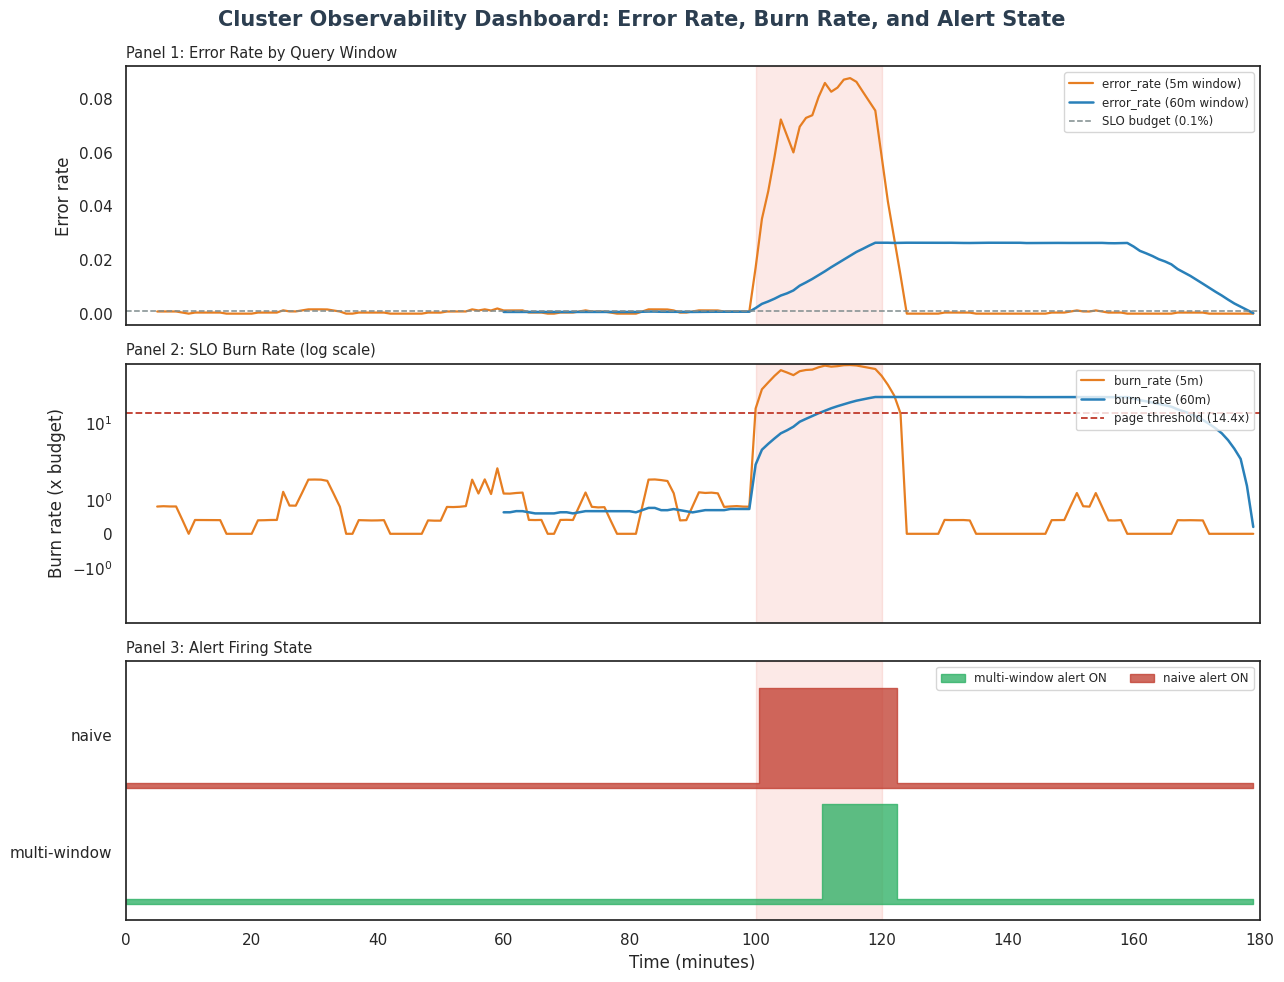

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
fig.suptitle("Cluster Observability Dashboard: Error Rate, Burn Rate, and Alert State",
             fontsize=15, fontweight='bold', color="#2c3e50")

incident_span = dict(xmin=INCIDENT_START, xmax=INCIDENT_END, color="#e74c3c", alpha=0.12, zorder=0)

# --- Panel 1: error rate, 5m vs 60m windows ---
ax0 = axes[0]
ax0.axvspan(**incident_span)
ax0.plot(timestamps, error_rate_5m, color="#e67e22", lw=1.6, label="error_rate (5m window)")
ax0.plot(timestamps, error_rate_60m, color="#2980b9", lw=1.8, label="error_rate (60m window)")
ax0.axhline(ERROR_BUDGET, color="#7f8c8d", lw=1.1, linestyle="--", label=f"SLO budget ({ERROR_BUDGET:.1%})")
ax0.set_ylabel("Error rate")
ax0.set_title("Panel 1: Error Rate by Query Window", fontsize=10.5, loc="left")
ax0.legend(loc="upper right", frameon=True, fontsize=8.5)

# --- Panel 2: burn rate, both windows, with threshold ---
ax1 = axes[1]
ax1.axvspan(**incident_span)
ax1.plot(timestamps, burn_rate_5m, color="#e67e22", lw=1.6, label="burn_rate (5m)")
ax1.plot(timestamps, burn_rate_60m, color="#2980b9", lw=1.8, label="burn_rate (60m)")
ax1.axhline(BURN_RATE_THRESHOLD, color="#c0392b", lw=1.3, linestyle="--", label=f"page threshold ({BURN_RATE_THRESHOLD}x)")
ax1.set_ylabel("Burn rate (x budget)")
ax1.set_yscale("symlog")
ax1.set_title("Panel 2: SLO Burn Rate (log scale)", fontsize=10.5, loc="left")
ax1.legend(loc="upper right", frameon=True, fontsize=8.5)

# --- Panel 3: alert state, multi-window vs naive ---
ax2 = axes[2]
ax2.axvspan(**incident_span)
ax2.fill_between(timestamps, 0, multi_window_alert.astype(int) * 0.9 + 0.05, color="#27ae60", alpha=0.75,
                  step="mid", label="multi-window alert ON")
ax2.fill_between(timestamps, 1.1, naive_alert.astype(int) * 0.9 + 1.15, color="#c0392b", alpha=0.75,
                  step="mid", label="naive alert ON")
ax2.set_ylim(-0.15, 2.3)
ax2.set_yticks([0.5, 1.6])
ax2.set_yticklabels(["multi-window", "naive"])
ax2.set_xlabel("Time (minutes)")
ax2.set_title("Panel 3: Alert Firing State", fontsize=10.5, loc="left")
ax2.legend(loc="upper right", frameon=True, fontsize=8.5, ncol=2)

for ax in axes:
    ax.set_xlim(0, N_MINUTES)

plt.tight_layout()
plt.show()


*(Insight: The red shaded band is the true 20-minute incident. In Panel 2, the orange 5m burn-rate line spikes sharply above the red page threshold during the incident but also jitters near it elsewhere from ordinary noise -- the blue 60m line is smoother but slower to rise and fall. Panel 3 makes the payoff visible directly: the green multi-window alert band lights up tightly around the true incident and nowhere else, while the red naive alert band flickers on outside the incident window too -- every one of those extra red flickers is a page that would have woken someone up for nothing.)*

## Real-World Use Case or Analogy

Think of multi-window burn-rate alerting as **A Household Budget With Two Different People Checking It**:

* **The Error Budget (The Month's Discretionary Spending Limit):** You've decided you can afford to overspend by a small, fixed amount this month without real financial harm -- that ceiling is the error budget.
* **Burn Rate (How Fast You're Spending Relative to "Fine for the Whole Month"):** Spending at 1x burn rate means you'll land exactly at the limit by month's end if you keep going -- spending at 10x means you'd blow through the entire month's allowance in three days.
* **The Short Window (The Family Member Who Checks the Balance Every Day):** They notice a spike immediately -- a big purchase yesterday jumps out right away -- but they also get anxious over perfectly normal day-to-day fluctuation, like one expensive grocery run.
* **The Long Window (The Family Member Who Reviews the Statement Monthly):** They never panic over one weird day, but by the time they'd notice a real problem, weeks of overspending may have already happened.
* **Requiring BOTH to Agree Before Acting (The Rule: Only Call an Emergency Meeting If Both People Are Worried):** One anxious daily-checker alone would call meetings constantly over nothing; one calm monthly-reviewer alone would catch problems too late. Requiring agreement from both is what turns two individually-flawed signals into one reliable one.
* **A Histogram Bucket Boundary (The Granularity Your Bank Statement Actually Reports At):** If your statement only ever reports spending in $50 buckets, you can estimate "roughly $73" by interpolating between the $50 and $100 lines, but you'll never know if it was exactly $73.14 -- your precision is capped by how the underlying data was collected, no matter how clever the estimate.

The generalizable idea is that reliable alerting is not about picking a single clever threshold -- it's about combining two imperfect signals, one fast-and-noisy and one slow-and-stable, so that only genuine, sustained problems clear both bars at once.